## 12. Calculated vs Recorded Delay

- `delay_calculated_sec`: actual arrival − scheduled arrival (from timetable matching)
- `delay_recorded_sec`: self-reported delay from vehicle (`lage` field)

Mean of calculated (~157s) >> mean of recorded (~47s) — big systematic gap.

In [2]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
OUT = Path('quality_report')
OUT.mkdir(exist_ok=True)

df = pl.read_parquet('../data/processed_with_signal_info/core_stop_events.parquet')

# Remove cross-day timetable mismatches upfront so all cells can use df_clean
df_clean = df.filter(
    pl.col('arrival_time').dt.date() == pl.col('scheduled_arrival_time').dt.date()
)
print(f'total events : {len(df):,}')
print(f'after filter : {len(df_clean):,}  (removed {len(df)-len(df_clean):,} cross-day mismatches)')

total events : 950,531
after filter : 950,052  (removed 479 cross-day mismatches)


## 1. Basic statistics

In [3]:
diff = df.with_columns(
    (pl.col('delay_calculated_sec') - pl.col('delay_recorded_sec')).alias('diff_sec')
)

for col in ['delay_calculated_sec', 'delay_recorded_sec', 'diff_sec']:
    s = diff[col]
    print(f'── {col} ──')
    print(f'  mean={s.mean():.1f}  median={s.median():.1f}  std={s.std():.1f}')
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(f'  p{p:<2d}: {s.quantile(p/100):.1f} s')
    print()

── delay_calculated_sec ──
  mean=153.1  median=124.2  std=142.6
  p1 : -26.6 s
  p5 : 13.2 s
  p25: 71.9 s
  p50: 124.2 s
  p75: 201.2 s
  p95: 391.2 s
  p99: 607.7 s

── delay_recorded_sec ──
  mean=46.9  median=30.0  std=172.8
  p1 : -690.0 s
  p5 : -70.0 s
  p25: 0.0 s
  p50: 30.0 s
  p75: 100.0 s
  p95: 270.0 s
  p99: 490.0 s

── diff_sec ──
  mean=106.2  median=72.6  std=154.7
  p1 : 0.2 s
  p5 : 36.9 s
  p25: 57.0 s
  p50: 72.6 s
  p75: 116.5 s
  p95: 231.3 s
  p99: 895.5 s



## 2. Distribution comparison (bulk)

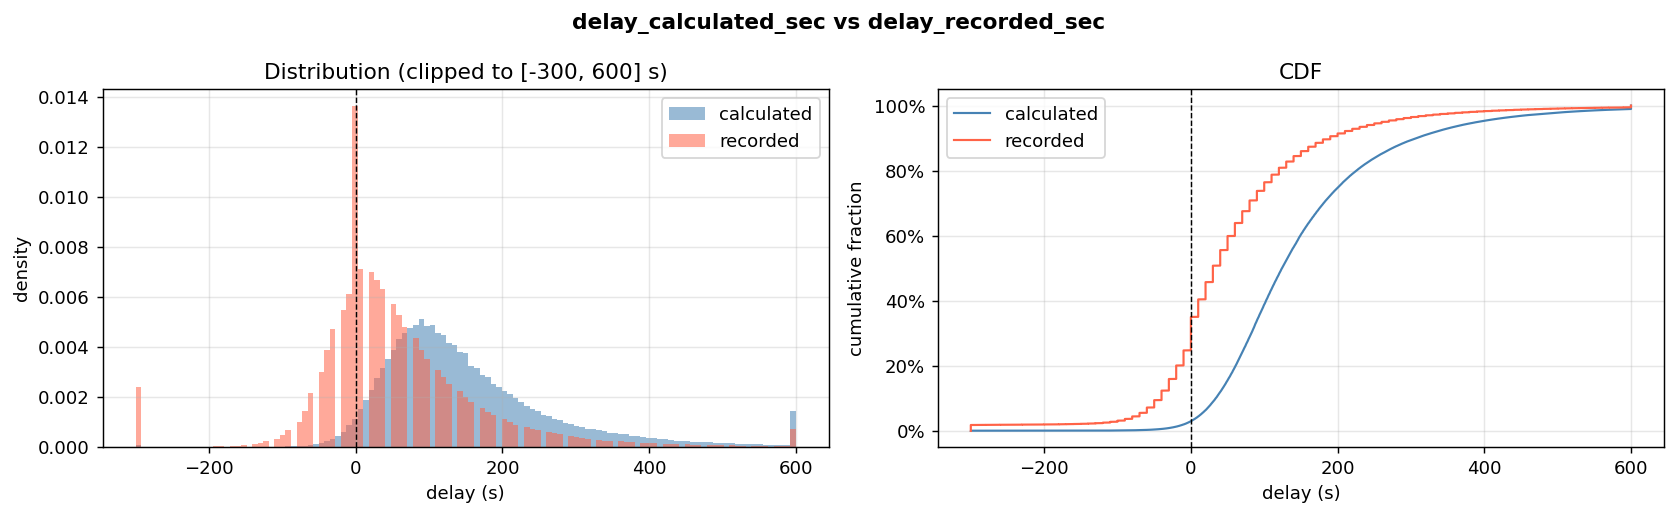

In [4]:
# Clip to [-300, 600] s for readability (covers p1–p99 of recorded)
CLIP_LO, CLIP_HI = -300, 600

calc = df['delay_calculated_sec'].clip(CLIP_LO, CLIP_HI).to_numpy()
recd = df['delay_recorded_sec'].clip(CLIP_LO, CLIP_HI).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overlapping histograms
bins = np.linspace(CLIP_LO, CLIP_HI, 120)
axes[0].hist(calc, bins=bins, alpha=0.55, color='steelblue', label='calculated', density=True)
axes[0].hist(recd, bins=bins, alpha=0.55, color='tomato',    label='recorded',   density=True)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('delay (s)')
axes[0].set_ylabel('density')
axes[0].set_title(f'Distribution (clipped to [{CLIP_LO}, {CLIP_HI}] s)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: CDF
for arr, label, color in [
    (calc, 'calculated', 'steelblue'),
    (recd, 'recorded',   'tomato'),
]:
    sorted_arr = np.sort(arr)
    cdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
    axes[1].plot(sorted_arr, cdf, label=label, color=color, linewidth=1.2)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('delay (s)')
axes[1].set_ylabel('cumulative fraction')
axes[1].set_title('CDF')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('delay_calculated_sec vs delay_recorded_sec', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '12_delay_dist.png', bbox_inches='tight')
plt.show()

## 3. Scatter plot: calculated vs recorded

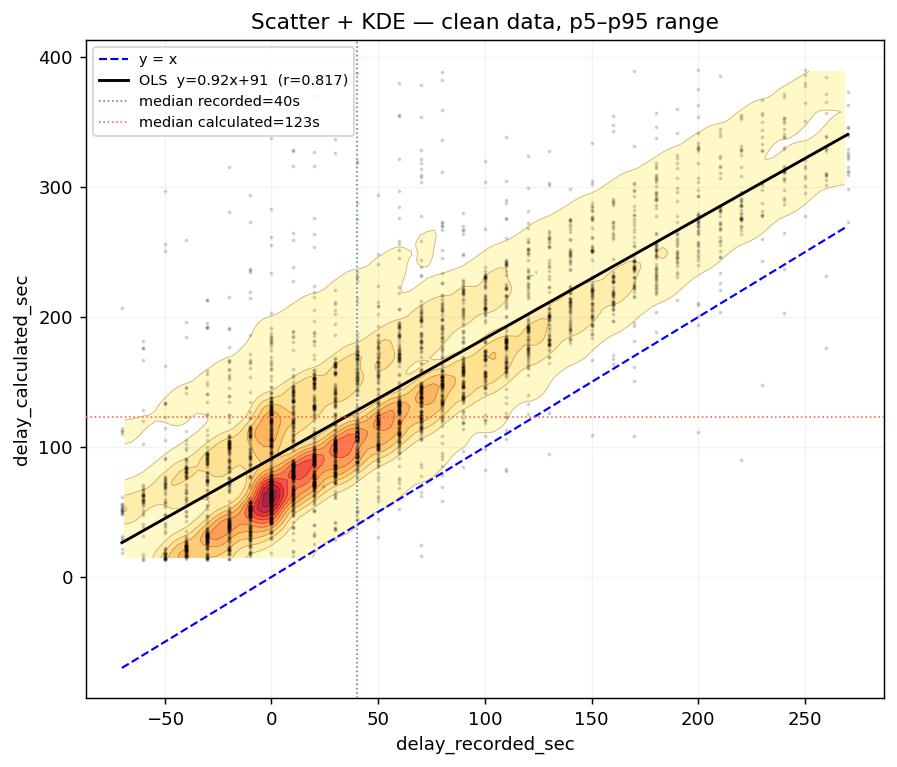

OLS slope=0.924  intercept=91.1s  r=0.8174
n points in plot: 818,116 / 950,052


In [5]:
from matplotlib.colors import LogNorm
from scipy import stats as scipy_stats
from scipy.ndimage import gaussian_filter

p5c,  p95c = df_clean['delay_calculated_sec'].quantile(0.05), df_clean['delay_calculated_sec'].quantile(0.95)
p5r,  p95r = df_clean['delay_recorded_sec'].quantile(0.05),   df_clean['delay_recorded_sec'].quantile(0.95)

calc_cl = df_clean['delay_calculated_sec'].to_numpy()
recd_cl = df_clean['delay_recorded_sec'].to_numpy()

mask = (calc_cl >= p5c) & (calc_cl <= p95c) & (recd_cl >= p5r) & (recd_cl <= p95r)
x = recd_cl[mask]
y = calc_cl[mask]

slope, intercept, r_val, _, _ = scipy_stats.linregress(x, y)

# density: 2-D histogram + gaussian smoothing
H, xe, ye = np.histogram2d(x, y, bins=120)
H_sm = gaussian_filter(H.T, sigma=2)
xc = (xe[:-1] + xe[1:]) / 2
yc = (ye[:-1] + ye[1:]) / 2
levels = np.linspace(H_sm.max() * 0.02, H_sm.max(), 12)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xc, yc, H_sm, levels=levels, cmap='YlOrRd', alpha=0.85)
ax.contour( xc, yc, H_sm, levels=levels, colors='saddlebrown', linewidths=0.4, alpha=0.45)

rng = np.random.default_rng(42)
idx = rng.choice(len(x), size=min(4000, len(x)), replace=False)
ax.scatter(x[idx], y[idx], s=1.5, alpha=0.12, color='k', rasterized=True, zorder=2)

xline = np.linspace(x.min(), x.max(), 300)
ax.plot(xline, xline,                     'b--', linewidth=1.2, label='y = x',            zorder=3)
ax.plot(xline, slope * xline + intercept, 'k-',  linewidth=1.6,
        label=f'OLS  y={slope:.2f}x+{intercept:.0f}  (r={r_val:.3f})', zorder=3)
ax.axvline(np.median(x), color='steelblue', linewidth=0.9, linestyle=':',
           label=f'median recorded={np.median(x):.0f}s',   zorder=3)
ax.axhline(np.median(y), color='tomato',    linewidth=0.9, linestyle=':',
           label=f'median calculated={np.median(y):.0f}s', zorder=3)

ax.set_xlabel('delay_recorded_sec')
ax.set_ylabel('delay_calculated_sec')
ax.set_title('Scatter + KDE — clean data, p5–p95 range')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(OUT / '12_delay_scatter.png', bbox_inches='tight')
plt.show()
print(f'OLS slope={slope:.3f}  intercept={intercept:.1f}s  r={r_val:.4f}')
print(f'n points in plot: {mask.sum():,} / {len(calc_cl):,}')

## 4. Difference: calculated − recorded

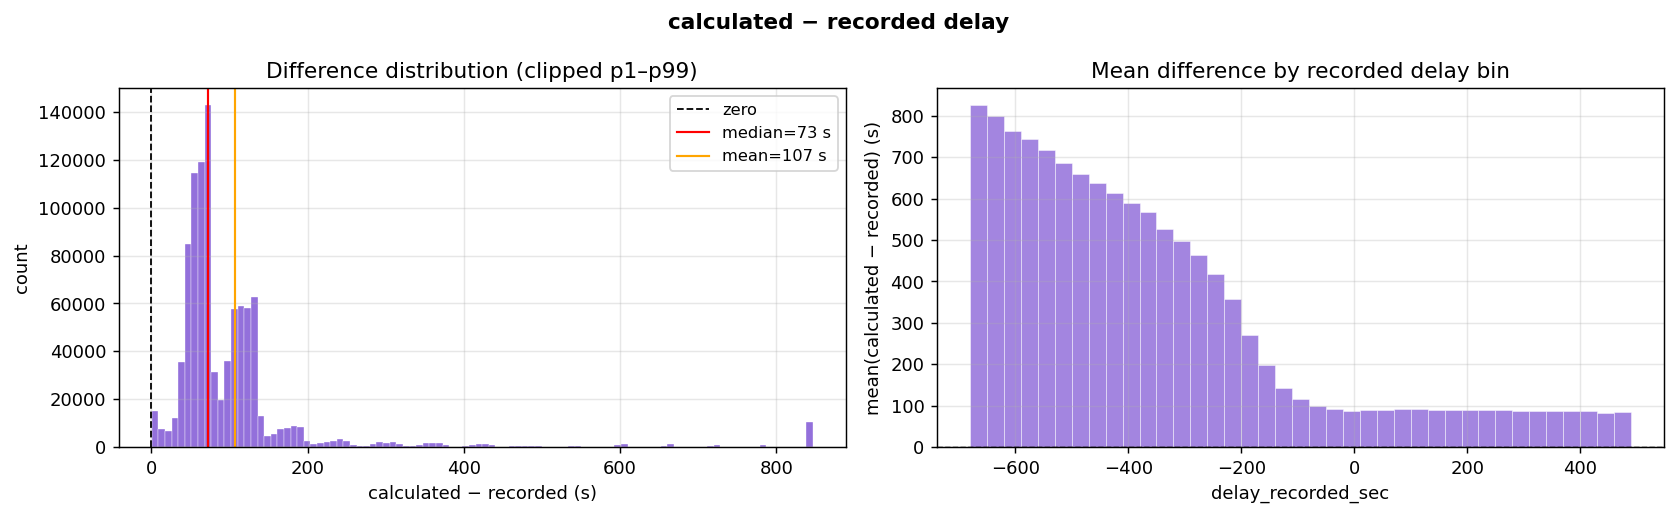

mean diff  : 106.5 s
median diff: 72.9 s
within ±30s : 3.2%
within ±60s : 28.7%


In [5]:
diff_arr = (
    df_clean['delay_calculated_sec'].to_numpy() -
    df_clean['delay_recorded_sec'].to_numpy()
)

p1d, p99d = np.percentile(diff_arr, 1), np.percentile(diff_arr, 99)
diff_clip  = np.clip(diff_arr, p1d, p99d)

recd_arr = df_clean['delay_recorded_sec'].to_numpy()
p1r_d, p99r_d = np.percentile(recd_arr, 1), np.percentile(recd_arr, 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of diff
axes[0].hist(diff_clip, bins=100, color='mediumpurple', edgecolor='white', linewidth=0.2)
axes[0].axvline(0,                   color='black',  linestyle='--', linewidth=1,   label='zero')
axes[0].axvline(np.median(diff_arr), color='red',    linestyle='-',  linewidth=1.2,
                label=f'median={np.median(diff_arr):.0f} s')
axes[0].axvline(np.mean(diff_arr),   color='orange', linestyle='-',  linewidth=1.2,
                label=f'mean={np.mean(diff_arr):.0f} s')
axes[0].set_xlabel('calculated − recorded (s)')
axes[0].set_ylabel('count')
axes[0].set_title('Difference distribution (clipped p1–p99)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: diff vs recorded (binned mean)
mask = (recd_arr >= p1r_d) & (recd_arr <= p99r_d)
bin_edges = np.linspace(p1r_d, p99r_d, 40)
bin_idx   = np.digitize(recd_arr[mask], bin_edges)
bin_mean  = [diff_arr[mask][bin_idx == k].mean() for k in range(1, len(bin_edges))]
bin_mid   = (bin_edges[:-1] + bin_edges[1:]) / 2

axes[1].bar(bin_mid, bin_mean, width=np.diff(bin_edges), color='mediumpurple',
            edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('delay_recorded_sec')
axes[1].set_ylabel('mean(calculated − recorded) (s)')
axes[1].set_title('Mean difference by recorded delay bin')
axes[1].grid(alpha=0.3)

plt.suptitle('calculated − recorded delay', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '12_delay_diff.png', bbox_inches='tight')
plt.show()

print(f'mean diff  : {np.mean(diff_arr):.1f} s')
print(f'median diff: {np.median(diff_arr):.1f} s')
print(f'within ±30s : {(np.abs(diff_arr) <= 30).mean()*100:.1f}%')
print(f'within ±60s : {(np.abs(diff_arr) <= 60).mean()*100:.1f}%')

## 5. Breakdown by stop_status

shape: (3, 6)
┌─────────────┬────────┬────────────┬─────────────┬────────────┬─────────────┐
│ stop_status ┆ n      ┆ calc_mean  ┆ recd_mean   ┆ diff_mean  ┆ diff_median │
│ ---         ┆ ---    ┆ ---        ┆ ---         ┆ ---        ┆ ---         │
│ str         ┆ u32    ┆ f64        ┆ f64         ┆ f64        ┆ f64         │
╞═════════════╪════════╪════════════╪═════════════╪════════════╪═════════════╡
│ multi_door  ┆ 2372   ┆ 285.57918  ┆ -203.293002 ┆ 488.872182 ┆ 186.725039  │
│ no_door     ┆ 196416 ┆ 139.892414 ┆ 46.406886   ┆ 93.485527  ┆ 72.801499   │
│ normal      ┆ 774605 ┆ 160.936134 ┆ 48.341586   ┆ 112.594548 ┆ 72.959697   │
└─────────────┴────────┴────────────┴─────────────┴────────────┴─────────────┘


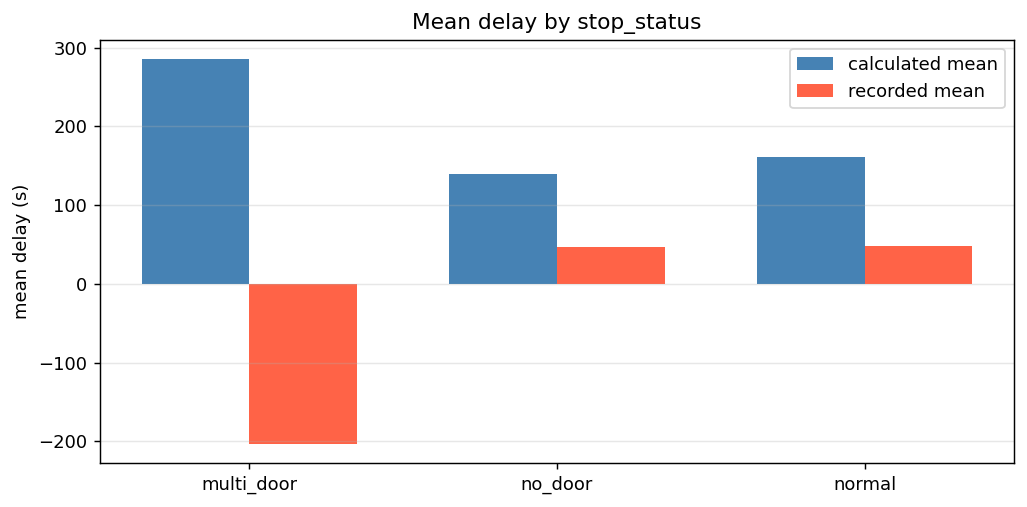

In [6]:
status_stats = (
    df
    .with_columns(
        (pl.col('delay_calculated_sec') - pl.col('delay_recorded_sec')).alias('diff_sec')
    )
    .group_by('stop_status')
    .agg(
        pl.len().alias('n'),
        pl.col('delay_calculated_sec').mean().alias('calc_mean'),
        pl.col('delay_recorded_sec').mean().alias('recd_mean'),
        pl.col('diff_sec').mean().alias('diff_mean'),
        pl.col('diff_sec').median().alias('diff_median'),
    )
    .sort('stop_status')
)
print(status_stats)

fig, ax = plt.subplots(figsize=(8, 4))
statuses = status_stats['stop_status'].to_list()
x = np.arange(len(statuses))
w = 0.35
ax.bar(x - w/2, status_stats['calc_mean'].to_list(), w, label='calculated mean', color='steelblue')
ax.bar(x + w/2, status_stats['recd_mean'].to_list(), w, label='recorded mean',   color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(statuses)
ax.set_ylabel('mean delay (s)')
ax.set_title('Mean delay by stop_status')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT / '12_delay_by_status.png', bbox_inches='tight')
plt.show()

## 6. Extreme outlier investigation

In [7]:
# Events where calculated and recorded diverge by more than 10 minutes
THRESH = 600
outliers = df.with_columns(
    (pl.col('delay_calculated_sec') - pl.col('delay_recorded_sec')).abs().alias('abs_diff')
).filter(pl.col('abs_diff') > THRESH)

print(f'Events with |calculated − recorded| > {THRESH}s: {len(outliers):,}  '
      f'({len(outliers)/len(df)*100:.1f}%)')
print()
print('stop_status breakdown:')
print(outliers.group_by('stop_status').agg(pl.len().alias('n')).sort('n', descending=True))
print()
print('Sample outlier rows:')
print(
    outliers
    .select(['fzg_id','fahrt_id','ort_nr_start','arrival_time','stop_status',
             'scheduled_arrival_time','delay_calculated_sec','delay_recorded_sec','abs_diff'])
    .sort('abs_diff', descending=True)
    .head(10)
)

Events with |calculated − recorded| > 600s: 16,075  (1.7%)

stop_status breakdown:
shape: (3, 2)
┌─────────────┬───────┐
│ stop_status ┆ n     │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ normal      ┆ 15419 │
│ multi_door  ┆ 591   │
│ no_door     ┆ 65    │
└─────────────┴───────┘

Sample outlier rows:
shape: (10, 9)
┌────────┬──────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ fzg_id ┆ fahrt_id ┆ ort_nr_sta ┆ arrival_ti ┆ … ┆ scheduled_ ┆ delay_cal ┆ delay_rec ┆ abs_diff  │
│ ---    ┆ ---      ┆ rt         ┆ me         ┆   ┆ arrival_ti ┆ culated_s ┆ orded_sec ┆ ---       │
│ i64    ┆ i64      ┆ ---        ┆ ---        ┆   ┆ me         ┆ ec        ┆ ---       ┆ f64       │
│        ┆          ┆ i64        ┆ datetime[μ ┆   ┆ ---        ┆ ---       ┆ i64       ┆           │
│        ┆          ┆            ┆ s, UTC]    ┆   ┆ datetime[μ ┆ f64       ┆           ┆           │
│        ┆          ┆            ┆          

## 7. Filter out timetable mismatches\n\nFrom the outlier sample: `arrival_time` and `scheduled_arrival_time` fall on **different calendar days** (e.g. arrival=2025-08-01, scheduled=2025-07-29). This means the join picked a record from the wrong day.\n\nFilter criterion: keep only rows where `arrival_time` and `scheduled_arrival_time` are on the **same UTC date**. This is more principled than an arbitrary second-threshold.

In [1]:
from scipy import stats

df_clean = df.filter(
    pl.col('arrival_time').dt.date() == pl.col('scheduled_arrival_time').dt.date()
)

n_removed = len(df) - len(df_clean)
print(f'Before : {len(df):>8,}')
print(f'Removed: {n_removed:>8,}  ({n_removed/len(df)*100:.2f}%)  — cross-day mismatches')
print(f'After  : {len(df_clean):>8,}')
print()

# Stats on clean data
for col in ['delay_calculated_sec', 'delay_recorded_sec']:
    s = df_clean[col]
    print(f'── {col} (clean) ──')
    print(f'  mean={s.mean():.1f}  median={s.median():.1f}  std={s.std():.1f}')
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(f'  p{p:<2d}: {s.quantile(p/100):.1f} s')
    print()

NameError: name 'df' is not defined

In [9]:
calc_c = df_clean['delay_calculated_sec'].to_numpy()
recd_c = df_clean['delay_recorded_sec'].to_numpy()

r_pearson,  _ = stats.pearsonr(calc_c, recd_c)
r_spearman, _ = stats.spearmanr(calc_c, recd_c)
print(f'Pearson  r (clean): {r_pearson:.4f}')
print(f'Spearman r (clean): {r_spearman:.4f}')
print()
print(f'(Before filtering — Pearson: 0.1398, Spearman: 0.8032)')

Pearson  r (clean): 0.5326
Spearman r (clean): 0.8040

(Before filtering — Pearson: 0.1398, Spearman: 0.8032)


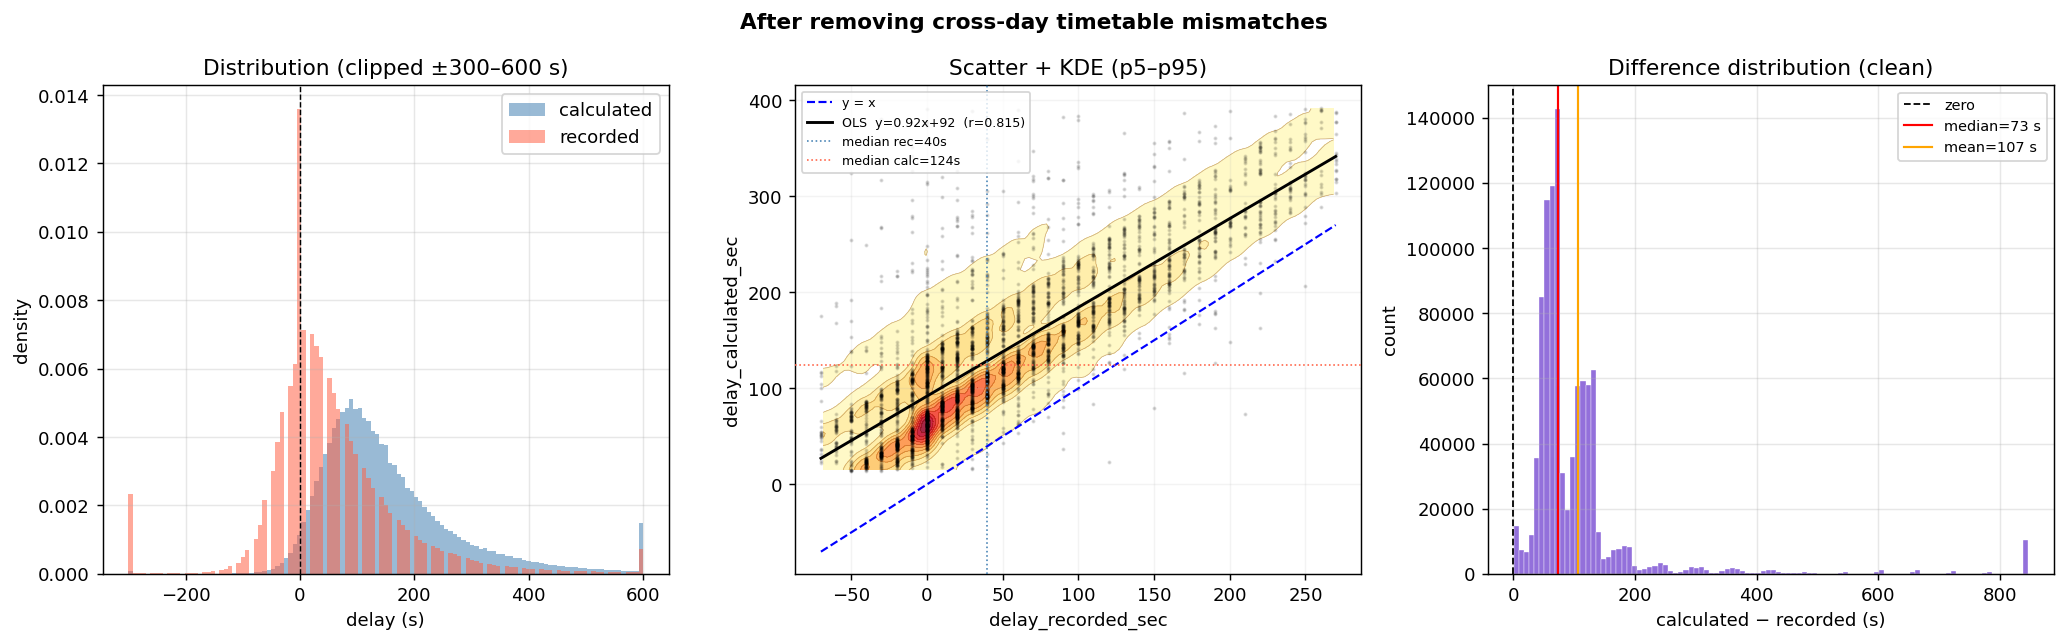

within ±30s : 3.2%
within ±60s : 28.7%
within ±120s: 76.9%


In [23]:
from scipy.ndimage import gaussian_filter

CLIP_LO, CLIP_HI = -300, 600

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: overlapping distributions ──────────────────────────────────────────
bins = np.linspace(CLIP_LO, CLIP_HI, 120)
axes[0].hist(np.clip(calc_c, CLIP_LO, CLIP_HI), bins=bins, alpha=0.55,
             color='steelblue', label='calculated', density=True)
axes[0].hist(np.clip(recd_c, CLIP_LO, CLIP_HI), bins=bins, alpha=0.55,
             color='tomato', label='recorded', density=True)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('delay (s)')
axes[0].set_ylabel('density')
axes[0].set_title('Distribution (clipped ±300–600 s)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Middle: scatter + KDE contour (p5–p95) ───────────────────────────────────
p5c, p95c = np.percentile(calc_c, 5),  np.percentile(calc_c, 95)
p5r, p95r = np.percentile(recd_c, 5),  np.percentile(recd_c, 95)
mask = (calc_c >= p5c) & (calc_c <= p95c) & (recd_c >= p5r) & (recd_c <= p95r)
x, y = recd_c[mask], calc_c[mask]

slope, intercept, r_val, _, _ = scipy_stats.linregress(x, y)

H, xe, ye = np.histogram2d(x, y, bins=120)
H_sm = gaussian_filter(H.T, sigma=2)
xc = (xe[:-1] + xe[1:]) / 2
yc = (ye[:-1] + ye[1:]) / 2
levels = np.linspace(H_sm.max() * 0.02, H_sm.max(), 12)

axes[1].contourf(xc, yc, H_sm, levels=levels, cmap='YlOrRd', alpha=0.85)
axes[1].contour( xc, yc, H_sm, levels=levels, colors='saddlebrown', linewidths=0.4, alpha=0.45)

rng = np.random.default_rng(42)
idx = rng.choice(len(x), size=min(4000, len(x)), replace=False)
axes[1].scatter(x[idx], y[idx], s=1.5, alpha=0.12, color='k', rasterized=True, zorder=2)

xline = np.linspace(x.min(), x.max(), 300)
axes[1].plot(xline, xline,                   'b--', linewidth=1.2, label='y = x',                          zorder=3)
axes[1].plot(xline, slope*xline + intercept, 'k-',  linewidth=1.6,
             label=f'OLS  y={slope:.2f}x+{intercept:.0f}  (r={r_val:.3f})', zorder=3)
axes[1].axvline(np.median(x), color='steelblue', linewidth=0.9, linestyle=':',
                label=f'median rec={np.median(x):.0f}s',  zorder=3)
axes[1].axhline(np.median(y), color='tomato',    linewidth=0.9, linestyle=':',
                label=f'median calc={np.median(y):.0f}s', zorder=3)
axes[1].set_xlabel('delay_recorded_sec')
axes[1].set_ylabel('delay_calculated_sec')
axes[1].set_title('Scatter + KDE (p5–p95)')
axes[1].legend(fontsize=7, loc='upper left')
axes[1].grid(alpha=0.15)

# ── Right: difference distribution ───────────────────────────────────────────
diff_c = calc_c - recd_c
p1d, p99d = np.percentile(diff_c, 1), np.percentile(diff_c, 99)
axes[2].hist(np.clip(diff_c, p1d, p99d), bins=100,
             color='mediumpurple', edgecolor='white', linewidth=0.2)
axes[2].axvline(0,                 color='black',  linestyle='--', linewidth=1,   label='zero')
axes[2].axvline(np.median(diff_c), color='red',    linestyle='-',  linewidth=1.2,
                label=f'median={np.median(diff_c):.0f} s')
axes[2].axvline(np.mean(diff_c),   color='orange', linestyle='-',  linewidth=1.2,
                label=f'mean={np.mean(diff_c):.0f} s')
axes[2].set_xlabel('calculated − recorded (s)')
axes[2].set_ylabel('count')
axes[2].set_title('Difference distribution (clean)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('After removing cross-day timetable mismatches', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '12_delay_clean.png', bbox_inches='tight')
plt.show()

diff_arr_c = calc_c - recd_c
print(f'within ±30s : {(np.abs(diff_arr_c) <= 30).mean()*100:.1f}%')
print(f'within ±60s : {(np.abs(diff_arr_c) <= 60).mean()*100:.1f}%')
print(f'within ±120s: {(np.abs(diff_arr_c) <= 120).mean()*100:.1f}%')

## 8. Normal stops only\n\n过滤掉 `multi_door` 和 `no_door`，只保留 `stop_status == 'normal'` 的事件，分析两种延误的关系。

In [17]:
df_normal = df_clean.filter(pl.col('stop_status') == 'normal')

n_removed = len(df_clean) - len(df_normal)
print(f'clean events      : {len(df_clean):>8,}')
print(f'non-normal removed: {n_removed:>8,}  ({n_removed/len(df_clean)*100:.2f}%)')
print(f'normal only       : {len(df_normal):>8,}')
print()

calc_n = df_normal['delay_calculated_sec'].to_numpy()
recd_n = df_normal['delay_recorded_sec'].to_numpy()

r_p_n, _ = stats.pearsonr(calc_n, recd_n)
r_s_n, _ = stats.spearmanr(calc_n, recd_n)
print(f'Pearson  r (normal only): {r_p_n:.4f}')
print(f'Spearman r (normal only): {r_s_n:.4f}')
print(f'(full clean — Pearson: {r_pearson:.4f}, Spearman: {r_spearman:.4f})')

for col, arr in [('delay_calculated_sec', calc_n), ('delay_recorded_sec', recd_n)]:
    print(f'\n── {col} (normal only) ──')
    print(f'  mean={arr.mean():.1f}  median={np.median(arr):.1f}  std={arr.std():.1f}')

clean events      :  972,839
non-normal removed:  198,651  (20.42%)
normal only       :  774,188

Pearson  r (normal only): 0.5001
Spearman r (normal only): 0.7958
(full clean — Pearson: 0.5326, Spearman: 0.8040)

── delay_calculated_sec (normal only) ──
  mean=157.4  median=128.5  std=147.4

── delay_recorded_sec (normal only) ──
  mean=48.4  median=40.0  std=182.1


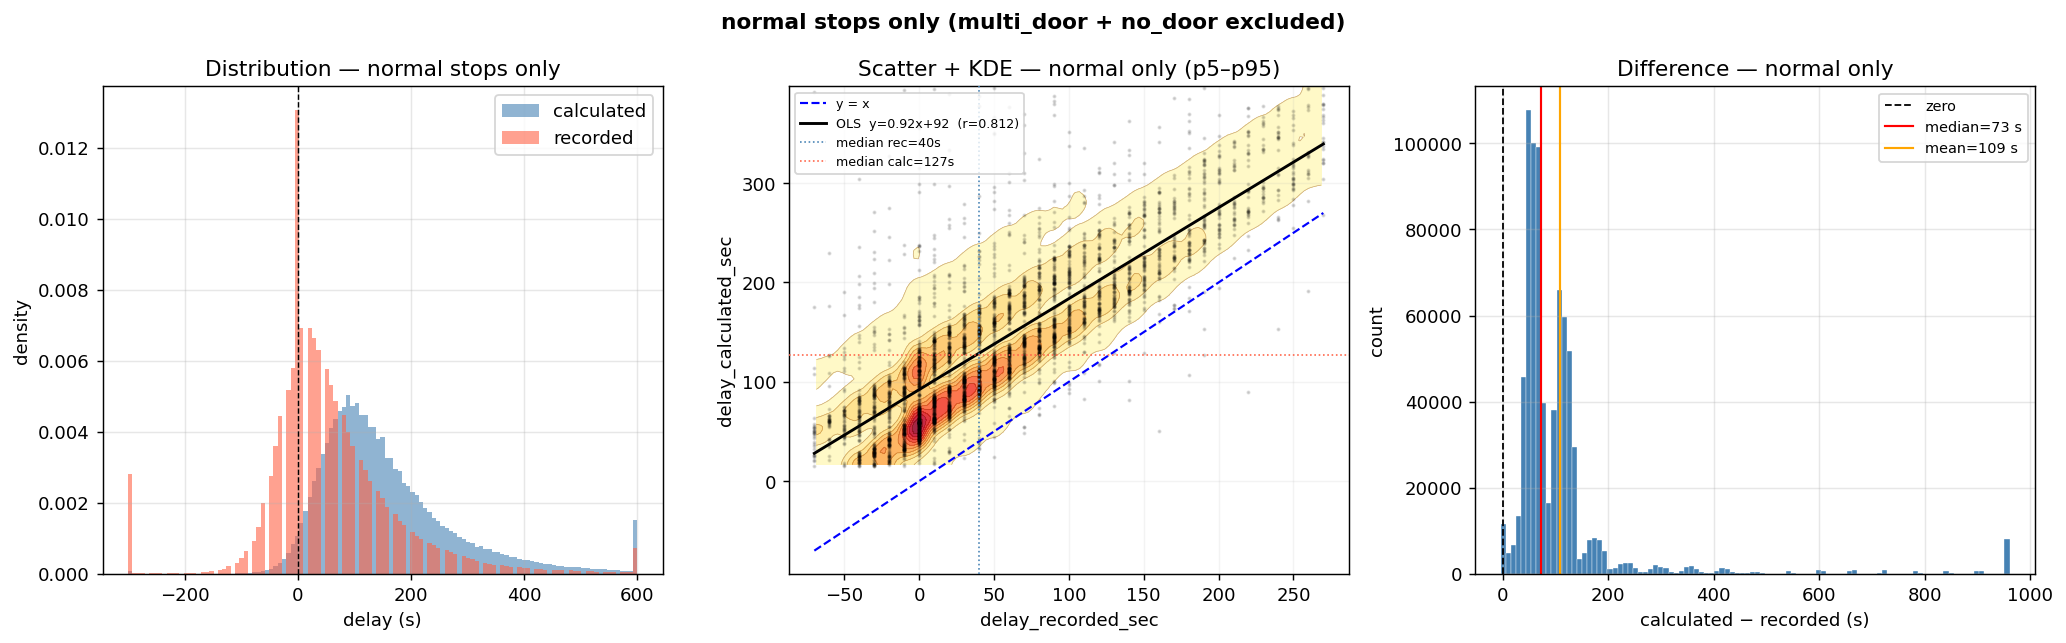

Pearson  r : 0.5001
Spearman r : 0.7958
within ±60s : 33.6%
within ±120s: 77.6%


In [19]:
from scipy.ndimage import gaussian_filter

CLIP_LO, CLIP_HI = -300, 600
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: distribution ────────────────────────────────────────────────────────
bins = np.linspace(CLIP_LO, CLIP_HI, 120)
axes[0].hist(np.clip(calc_n, CLIP_LO, CLIP_HI), bins=bins, alpha=0.6,
             color='steelblue', density=True, label='calculated')
axes[0].hist(np.clip(recd_n, CLIP_LO, CLIP_HI), bins=bins, alpha=0.6,
             color='tomato', density=True, label='recorded')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('delay (s)')
axes[0].set_ylabel('density')
axes[0].set_title('Distribution — normal stops only')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Middle: scatter subsample + smoothed-hist KDE contour ────────────────────
p5c, p95c = np.percentile(calc_n, 5), np.percentile(calc_n, 95)
p5r, p95r = np.percentile(recd_n, 5), np.percentile(recd_n, 95)
mask = (calc_n >= p5c) & (calc_n <= p95c) & (recd_n >= p5r) & (recd_n <= p95r)
x_n, y_n = recd_n[mask], calc_n[mask]

slope_n, intercept_n, r_n, _, _ = scipy_stats.linregress(x_n, y_n)

# density via 2-D histogram + gaussian smoothing (fast, clean)
H, xe, ye = np.histogram2d(x_n, y_n, bins=120)
H_sm = gaussian_filter(H.T, sigma=2)
xc = (xe[:-1] + xe[1:]) / 2
yc = (ye[:-1] + ye[1:]) / 2
levels = np.linspace(H_sm.max() * 0.02, H_sm.max(), 12)

axes[1].contourf(xc, yc, H_sm, levels=levels, cmap='YlOrRd', alpha=0.85)
axes[1].contour( xc, yc, H_sm, levels=levels, colors='saddlebrown', linewidths=0.4, alpha=0.45)

# sparse scatter overlay for individual-point feel
rng = np.random.default_rng(42)
idx = rng.choice(len(x_n), size=min(4000, len(x_n)), replace=False)
axes[1].scatter(x_n[idx], y_n[idx], s=1.5, alpha=0.12, color='k', rasterized=True, zorder=2)

# reference & regression lines
xline = np.linspace(x_n.min(), x_n.max(), 300)
axes[1].plot(xline, xline,                       'b--', linewidth=1.2, label='y = x', zorder=3)
axes[1].plot(xline, slope_n*xline + intercept_n, 'k-',  linewidth=1.6,
             label=f'OLS  y={slope_n:.2f}x+{intercept_n:.0f}  (r={r_n:.3f})', zorder=3)
axes[1].axvline(np.median(x_n), color='steelblue', linewidth=0.9, linestyle=':',
                label=f'median rec={np.median(x_n):.0f}s', zorder=3)
axes[1].axhline(np.median(y_n), color='tomato',    linewidth=0.9, linestyle=':',
                label=f'median calc={np.median(y_n):.0f}s', zorder=3)
axes[1].set_xlabel('delay_recorded_sec')
axes[1].set_ylabel('delay_calculated_sec')
axes[1].set_title('Scatter + KDE — normal only (p5–p95)')
axes[1].legend(fontsize=7, loc='upper left')
axes[1].grid(alpha=0.15)

# ── Right: difference distribution ───────────────────────────────────────────
diff_n = calc_n - recd_n
p1d, p99d = np.percentile(diff_n, 1), np.percentile(diff_n, 99)
axes[2].hist(np.clip(diff_n, p1d, p99d), bins=100,
             color='steelblue', edgecolor='white', linewidth=0.2)
axes[2].axvline(0,                 color='black',  linestyle='--', linewidth=1,   label='zero')
axes[2].axvline(np.median(diff_n), color='red',    linestyle='-',  linewidth=1.2,
                label=f'median={np.median(diff_n):.0f} s')
axes[2].axvline(np.mean(diff_n),   color='orange', linestyle='-',  linewidth=1.2,
                label=f'mean={np.mean(diff_n):.0f} s')
axes[2].set_xlabel('calculated − recorded (s)')
axes[2].set_ylabel('count')
axes[2].set_title('Difference — normal only')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('normal stops only (multi_door + no_door excluded)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / '12_delay_normal_only.png', bbox_inches='tight')
plt.show()

print(f'Pearson  r : {r_p_n:.4f}')
print(f'Spearman r : {r_s_n:.4f}')
print(f'within ±60s : {(np.abs(diff_n) <= 60).mean()*100:.1f}%')
print(f'within ±120s: {(np.abs(diff_n) <= 120).mean()*100:.1f}%')

In [20]:
# 看multi_door事件里calculated和recorded的散点关系
multi = df.filter(pl.col("stop_status") == "multi_door")
print(multi.select([
    "delay_calculated_sec", 
    "delay_recorded_sec",
    "arrival_time",
    "dwell_time"
]).describe())

# 看几个极端案例
print(multi.sort("delay_recorded_sec").head(10).select([
    "fzg_id", "arrival_time", "departure_time",
    "delay_calculated_sec", "delay_recorded_sec", "dwell_time"
]))

shape: (9, 5)
┌────────────┬──────────────────────┬────────────────────┬──────────────────────────┬──────────────┐
│ statistic  ┆ delay_calculated_sec ┆ delay_recorded_sec ┆ arrival_time             ┆ dwell_time   │
│ ---        ┆ ---                  ┆ ---                ┆ ---                      ┆ ---          │
│ str        ┆ f64                  ┆ f64                ┆ str                      ┆ f64          │
╞════════════╪══════════════════════╪════════════════════╪══════════════════════════╪══════════════╡
│ count      ┆ 2372.0               ┆ 2372.0             ┆ 2372                     ┆ 2372.0       │
│ null_count ┆ 0.0                  ┆ 0.0                ┆ 0                        ┆ 0.0          │
│ mean       ┆ 285.57918            ┆ -203.293002        ┆ 2025-07-31               ┆ 31.194175    │
│            ┆                      ┆                    ┆ 09:20:28.884408+00:…     ┆              │
│ std        ┆ 3129.338975          ┆ 464.229845         ┆ null              

In [21]:
normal = df.filter(pl.col("stop_status") == "normal")

# 1. delay_calculated_sec的分位数，看极端值规模
print("=== delay_calculated_sec ===")
for q in [0.001, 0.01, 0.05, 0.95, 0.99, 0.999]:
    print(f"  q{q}: {normal['delay_calculated_sec'].quantile(q):.1f}s")

# 2. 极端正值：超过1小时的
extreme_pos = normal.filter(pl.col("delay_calculated_sec") > 3600)
print(f"\ndelay > 3600s: {len(extreme_pos)} rows")
print(extreme_pos.select([
    "fzg_id", "linie", "arrival_time", "scheduled_arrival_time",
    "delay_calculated_sec", "delay_recorded_sec"
]).head(10))

# 3. 极端负值：早点超过10分钟的
extreme_neg = normal.filter(pl.col("delay_calculated_sec") < -600)
print(f"\ndelay < -600s: {len(extreme_neg)} rows")
print(extreme_neg.select([
    "fzg_id", "linie", "arrival_time", "scheduled_arrival_time", 
    "delay_calculated_sec", "delay_recorded_sec"
]).head(10))

# 4. 看这些极端值是否集中在某些线路或时段
print("\n极端正值按linie分布:")
print(extreme_pos["linie"].value_counts().sort("count", descending=True).head(10))

print("\n极端正值按arrival hour分布:")
print(extreme_pos.with_columns(
    pl.col("arrival_time").dt.hour().alias("hour")
)["hour"].value_counts().sort("count", descending=True).head(10))

=== delay_calculated_sec ===
  q0.001: -121.2s
  q0.01: -24.7s
  q0.05: 14.9s
  q0.95: 399.7s
  q0.99: 616.3s
  q0.999: 1155.1s

delay > 3600s: 73 rows
shape: (10, 6)
┌────────┬───────┬────────────────────┬────────────────────┬───────────────────┬───────────────────┐
│ fzg_id ┆ linie ┆ arrival_time       ┆ scheduled_arrival_ ┆ delay_calculated_ ┆ delay_recorded_se │
│ ---    ┆ ---   ┆ ---                ┆ time               ┆ sec               ┆ c                 │
│ i64    ┆ i64   ┆ datetime[μs, UTC]  ┆ ---                ┆ ---               ┆ ---               │
│        ┆       ┆                    ┆ datetime[μs, UTC]  ┆ f64               ┆ i64               │
╞════════╪═══════╪════════════════════╪════════════════════╪═══════════════════╪═══════════════════╡
│ 259    ┆ 2     ┆ 2025-08-02         ┆ 2025-07-31         ┆ 97784.226061      ┆ 0                 │
│        ┆       ┆ 01:41:44.226061    ┆ 22:32:00 UTC       ┆                   ┆                   │
│        ┆       ┆ UTC   